# Упражнение 8.4. Приз за исследование как бонус к выбору действия

Саттон, Барто, «Обучение с подкреплением».
Полный разбор — в сборнике решений: [глава 8 (PDF)](https://michaeltoschenko.github.io/RL_Sutton_Barto_Solutions/ch08.pdf).


In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

%matplotlib inline

## Среда

Лабиринт 6x9, старт внизу, цель в правом верхнем углу. Первые 5000 шагов открыт только обходной путь слева. На шаге 5000 дополнительно открывается короткий путь справа (длинный при этом остаётся).

In [2]:
H, W = 6, 9
START = 5 * W + 3            # состояние кодируем одним числом: r * W + c
GOAL = 0 * W + 8
DR = (-1, 1, 0, 0)           # вверх, вниз, влево, вправо
DC = (0, 0, -1, 1)

def obstacles(shortcut_open):
    cols = range(1, 8) if shortcut_open else range(1, 9)
    return {3 * W + c for c in cols}

def step(s, a, obst):
    r, c = divmod(s, W)
    nr, nc = r + DR[a], c + DC[a]
    ns = nr * W + nc
    if nr < 0 or nr >= H or nc < 0 or nc >= W or ns in obst:
        ns = s               # стена или граница - остаёмся на месте
    reward = 1.0 if ns == GOAL else 0.0
    return ns, reward

## Агенты

Все три используют одношаговое Q-обучение плюс `planning_steps` обновлений по модели на каждом реальном шаге. Здесь `tau` - число шагов с момента, когда пара состояние-действие последний раз пробовалась в реальной среде.

- Dyna-Q: без приза.
- Dyna-Q+: приз `kappa * sqrt(tau)` прибавляется к награде на шаге планирования.
- Dyna-Q+ (бонус при выборе): тот же `tau`, но приз входит только в правило выбора - берём действие с максимумом `Q + kappa * sqrt(tau)`, а в обновления он не попадает.

In [3]:
def argmax_random(vals, rnd):
    best = max(vals)
    cand = [i for i in range(len(vals)) if vals[i] == best]
    return cand[0] if len(cand) == 1 else rnd.choice(cand)

def dyna_run(variant, seed, n_steps=10000, switch=5000, planning_steps=50,
             alpha=1.0, gamma=0.95, epsilon=0.1, kappa=1e-3):
    rnd = random.Random(seed)
    obst = obstacles(shortcut_open=False)

    Q = [[0.0] * 4 for _ in range(H * W)]
    model_r = [[0.0] * 4 for _ in range(H * W)]
    model_s2 = [[s] * 4 for s in range(H * W)]   # неиспробованное действие -> остаёмся на месте
    last = [[0] * 4 for _ in range(H * W)]         # шаг, когда (s, a) последний раз пробовали

    observed = []                                  # посещённые состояния (для планирования)
    seen = [False] * (H * W)
    tried = [[] for _ in range(H * W)]

    cum = [0.0] * n_steps
    total = 0.0
    s = START

    for t in range(n_steps):
        if t == switch:
            obst = obstacles(shortcut_open=True)
        if s == GOAL:
            s = START

        qs = Q[s]
        # выбор действия
        if variant == 'select':
            # бонус только здесь, в обновления он не попадает
            vals = [qs[a] + kappa * math.sqrt(t - last[s][a]) for a in range(4)]
            a = argmax_random(vals, rnd)
        elif rnd.random() < epsilon:
            a = rnd.randint(0, 3)
        else:
            a = argmax_random(qs, rnd)

        ns, reward = step(s, a, obst)

        # прямое обучение (один шаг)
        qs[a] += alpha * (reward + gamma * max(Q[ns]) - qs[a])

        # обновление модели
        if not seen[s]:
            seen[s] = True
            observed.append(s)
        if a not in tried[s]:
            tried[s].append(a)
        model_r[s][a] = reward
        model_s2[s][a] = ns
        last[s][a] = t

        # планирование: planning_steps обновлений по модели
        for _ in range(planning_steps):
            ps = observed[rnd.randint(0, len(observed) - 1)]
            if variant == 'dyna_q_plus':
                pa = rnd.randint(0, 3)                                # любое действие, в т.ч. неиспробованное
                r_plan = model_r[ps][pa] + kappa * math.sqrt(t - last[ps][pa])
            else:
                acts = tried[ps]
                pa = acts[rnd.randint(0, len(acts) - 1)]
                r_plan = model_r[ps][pa]
            Q[ps][pa] += alpha * (r_plan + gamma * max(Q[model_s2[ps][pa]]) - Q[ps][pa])

        total += reward
        cum[t] = total
        s = ns

    return np.asarray(cum)

## Запуск

Усредняем по 30 независимым запускам.

In [4]:
runs = 30
n_steps = 10000
agents = [('Dyna-Q', 'dyna_q'),
          ('Dyna-Q+', 'dyna_q_plus'),
          ('Dyna-Q+ (бонус при выборе)', 'select')]

curves = {}
for label, variant in agents:
    acc = np.zeros(n_steps)
    for seed in tqdm(range(runs), desc=label):
        acc += dyna_run(variant, seed, n_steps=n_steps)
    curves[label] = acc / runs

Dyna-Q+ (бонус при выборе): 100%|██████████| 30/30 [00:11<00:00,  2.57it/s]


## Графики

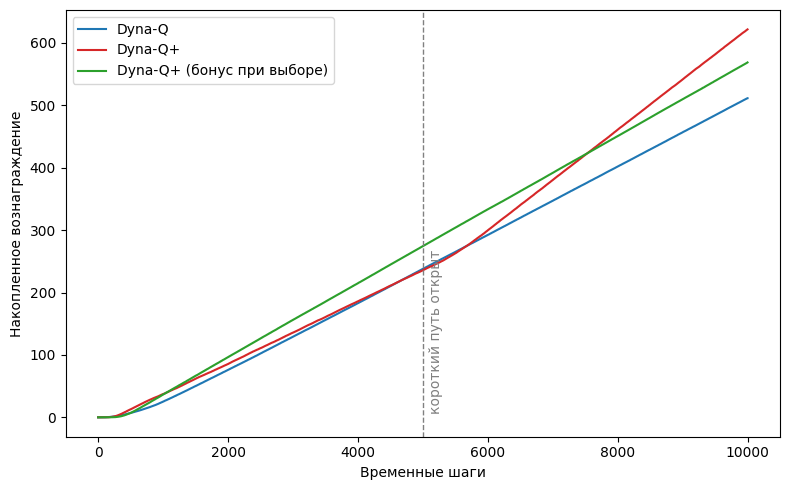

In [5]:
colors = {'Dyna-Q': 'tab:blue',
          'Dyna-Q+': 'tab:red',
          'Dyna-Q+ (бонус при выборе)': 'tab:green'}

plt.figure(figsize=(8, 5))
for label, c in curves.items():
    plt.plot(c, color=colors[label], label=label)
plt.axvline(5000, color='gray', linestyle='--', linewidth=1)
plt.text(5100, 5, 'короткий путь открыт', color='gray', rotation=90, va='bottom')
plt.xlabel('Временные шаги')
plt.ylabel('Накопленное вознаграждение')
plt.legend()
plt.tight_layout()
plt.show()

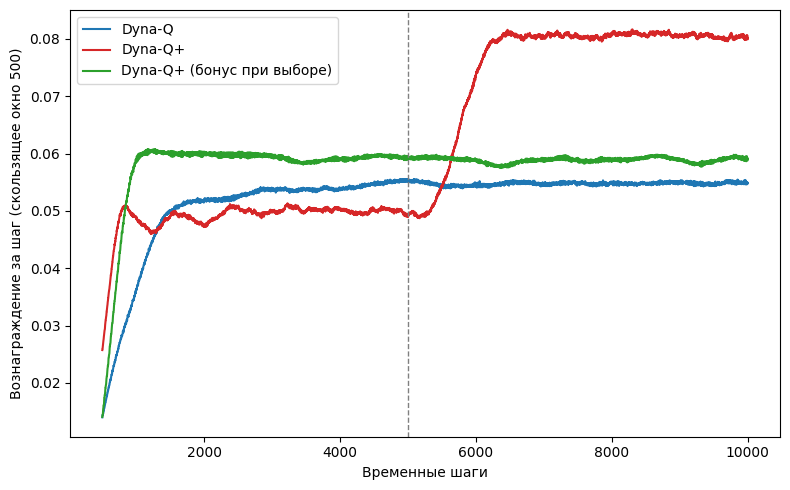

In [6]:
window = 500
plt.figure(figsize=(8, 5))
for label, c in curves.items():
    rate = (c[window:] - c[:-window]) / window
    plt.plot(range(window, n_steps), rate, color=colors[label], label=label)
plt.axvline(5000, color='gray', linestyle='--', linewidth=1)
plt.xlabel('Временные шаги')
plt.ylabel('Вознаграждение за шаг (скользящее окно %d)' % window)
plt.legend()
plt.tight_layout()
plt.show()